## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)

print('Scikit-learn ready')

Scikit-learn ready


In [1]:
comparison = pd.DataFrame({
    'Type': ['Supervised - Regression', 'Supervised - Classification', 'Unsupervised - Clustering'],
    'Goal': ['Predict a continuous number', 'Predict a category/label', 'Group similar data points'],
    'Example': ['Predicting house price', 'Predicting if an email is spam', 'Segmenting customers by behaviour']
})
comparison

NameError: name 'pd' is not defined

##  Sample Dataset - House Price Prediction

We'll create a synthetic housing dataset with features like area, number of bedrooms,
number of bathrooms, and age of the house, and a target column `Price`.

In [ ]:
np.random.seed(42)

n_samples = 200

area = np.random.randint(500, 4000, n_samples)                 # square feet
bedrooms = np.random.randint(1, 6, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
age = np.random.randint(0, 30, n_samples)                      # years

# Price roughly follows a linear relationship with some noise
price = (area * 150) + (bedrooms * 20000) + (bathrooms * 15000) - (age * 1000) + np.random.normal(0, 25000, n_samples)
price = np.round(price, -2)  # round to nearest hundred

house_df = pd.DataFrame({
    'Area': area,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Age': age,
    'Price': price
})

house_df.head()

,Area,Bedrooms,Bathrooms,Age,Price
0,3674,4,2,22,644600.0
1,1360,4,3,15,301900.0
2,1794,3,3,24,391100.0
3,1630,2,2,6,314100.0
4,1595,4,3,12,356400.0


In [4]:
house_df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2333.775000,2.780000,1.895000,14.980000,420788.500000
std,992.421831,1.393308,0.816891,8.720656,154378.612827
min,521.000000,1.000000,1.000000,0.000000,133100.000000
25%,1519.000000,1.000000,1.000000,7.750000,297375.000000
50%,2372.000000,3.000000,2.000000,15.000000,433350.000000
75%,3229.500000,4.000000,3.000000,23.000000,557825.000000
max,3999.000000,5.000000,3.000000,29.000000,724700.000000


## 5. Exploring Relationships

Before modeling, let's visualize how `Area` relates to `Price`.

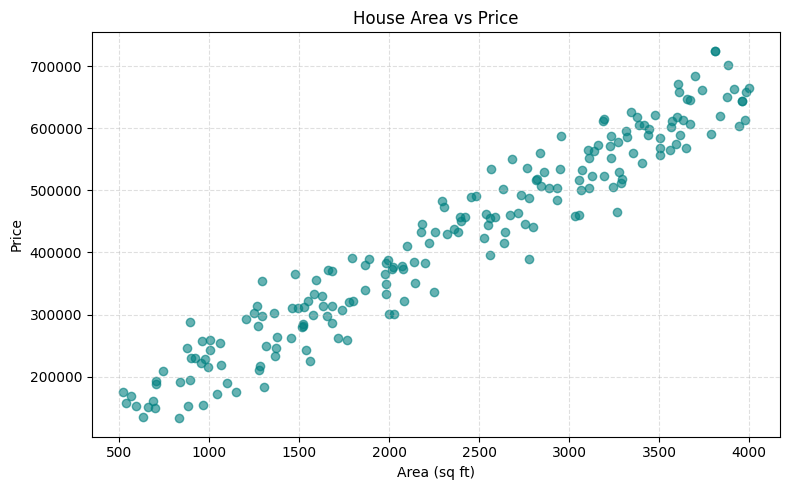

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(house_df['Area'], house_df['Price'], color='teal', alpha=0.6)
plt.title('House Area vs Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Train/Test Split

We split the data into a **training set** (used to fit the model) and a **test set**
(used to evaluate how well the model generalizes to unseen data). A common split is 80/20.

In [6]:
X = house_df[['Area', 'Bedrooms', 'Bathrooms', 'Age']]
y = house_df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples : {X_test.shape[0]}')

Training samples: 160
Testing samples : 40


## 7. Scikit-learn Basics - The Estimator API

Scikit-learn models follow a consistent pattern:

1. `model = SomeAlgorithm()` - create the model
2. `model.fit(X_train, y_train)` - train it on the training data
3. `model.predict(X_test)` - make predictions on new data
4. `model.score(X_test, y_test)` - get a quick performance score

Let's use this pattern to train a **Linear Regression** model for House Price Prediction.

In [7]:
house_model = LinearRegression()
house_model.fit(X_train, y_train)

print('Model coefficients:', dict(zip(X.columns, house_model.coef_)))
print('Model intercept:', house_model.intercept_)

Model coefficients: {'Area': np.float64(150.02903351399135), 'Bedrooms': np.float64(20189.396953859676), 'Bathrooms': np.float64(12094.565927790609), 'Age': np.float64(-1135.385904381794)}
Model intercept: 8663.415677214682


In [8]:
y_pred = house_model.predict(X_test)

results = pd.DataFrame({'Actual Price': y_test.values, 'Predicted Price': np.round(y_pred, 2)})
results.head(10)

,Actual Price,Predicted Price
0,516000.0,503563.28
1,605200.0,595016.14
2,701000.0,660241.00
3,242900.0,241378.64
4,230800.0,229023.75
5,168500.0,151776.11
6,389300.0,375445.55
7,512000.0,527483.03
8,152900.0,137667.26
9,583700.0,599083.10


## 8. Model Evaluation Metrics (Regression)

Common metrics for evaluating a regression model:

- **MAE (Mean Absolute Error)** - average absolute difference between actual and predicted values.
- **MSE (Mean Squared Error)** - average squared difference; penalizes larger errors more.
- **RMSE (Root Mean Squared Error)** - square root of MSE, in the same units as the target.
- **R² Score** - proportion of variance in the target explained by the model (closer to 1 is better).

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:,.2f}')
print(f'MSE  : {mse:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R2   : {r2:.4f}')

MAE  : 17,098.62
MSE  : 471,535,795.28
RMSE : 21,714.87
R2   : 0.9822


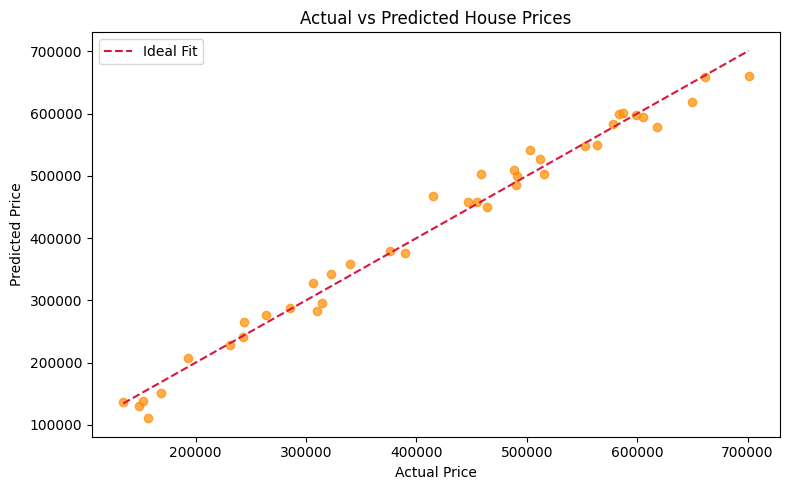

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='darkorange', alpha=0.7)
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', label='Ideal Fit')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Classification Overview

Classification predicts a category instead of a number. As a simple demonstration,
let's turn our regression problem into a classification one: is a house **"Expensive"**
(above the median price) or **"Affordable"** (at or below the median)?

In [11]:
from sklearn.linear_model import LogisticRegression

y_class = (house_df['Price'] > house_df['Price'].median()).astype(int)  # 1 = Expensive, 0 = Affordable

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print(f'Accuracy : {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall   : {recall:.2f}')
print(f'F1-score : {f1:.2f}')

Accuracy : 0.97
Precision: 0.95
Recall   : 1.00
F1-score : 0.98


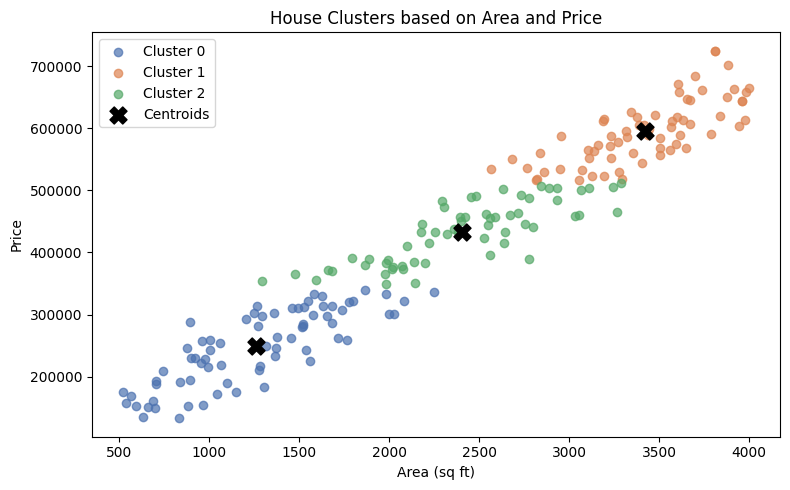

In [12]:
cluster_features = house_df[['Area', 'Price']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
house_df['Cluster'] = kmeans.fit_predict(cluster_features)

plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
for cluster_id in sorted(house_df['Cluster'].unique()):
    subset = house_df[house_df['Cluster'] == cluster_id]
    plt.scatter(subset['Area'], subset['Price'], label=f'Cluster {cluster_id}',
                color=colors[cluster_id], alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='black', marker='X', s=150, label='Centroids')
plt.title('House Clusters based on Area and Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Summary

- Walked through the **ML lifecycle** from problem definition to evaluation.
- Compared **supervised** (regression, classification) and **unsupervised** (clustering) learning.
- Built a **House Price Prediction** model using `LinearRegression` from Scikit-learn.
- Used **train/test split** to evaluate the model on unseen data.
- Evaluated the regression model with **MAE, MSE, RMSE, and R²**.
- Explored **classification** metrics (Accuracy, Precision, Recall, F1-score) with a simple Expensive/Affordable classifier.
- Demonstrated **clustering** with K-Means as an unsupervised learning example.